In [1]:
from roboflow import Roboflow
rf = Roboflow(api_key="rkltX8gvBzuRcWzTI3ED")
project = rf.workspace("datasets-ef3fe").project("self-checkout-detector-ylyga")
version = project.version(14)
dataset = version.download("yolov12")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to self-checkout-detector-14 in yolov12:: 100%|█| 10538/10538 [00:10<00:00, 1037.91it/s]


In [3]:
import os
from collections import Counter

labels_folder = "self-checkout-detector-14/train/labels"  # <- change the folder name if needed

counts = Counter()

for file in os.listdir(labels_folder):
    with open(os.path.join(labels_folder, file), "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            counts[class_id] += 1

print("Class counts:", counts)

Class counts: Counter({1: 2274, 2: 1443, 0: 1125, 3: 906, 6: 741, 4: 597, 5: 597})


In [ ]:
from ultralytics import YOLO

# Load base YOLOv12n model
model = YOLO("yolo12n.pt")

# Train
model.train(
    data="self-checkout-detector-14/data.yaml",

    # -------- Core training --------
    epochs=160,
    imgsz=832,          # ⭐ critical for large ROI
    batch=6,            # safe for RTX 4050 (6GB)
    patience=60,

    # -------- Optimizer --------
    optimizer="AdamW",
    lr0=0.0005,
    lrf=0.01,
    warmup_epochs=3,
    weight_decay=0.00045,

    # -------- Augmentations (SCC-safe) --------
    mosaic=0.45,
    close_mosaic=15,
    mixup=0.05,

    hsv_s=0.45,
    hsv_v=0.55,

    degrees=5,
    translate=0.12,
    scale=0.45,
    shear=0.5,
    perspective=0.0005,

    fliplr=0.5,
    flipud=0.05,

    # -------- Stability --------
    amp=False,          # disable AMP for stability
    workers=2,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.7 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.240  Python-3.10.10 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=self-checkout-detector-14/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=160, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.05, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.45, hsv_v=0.55, imgsz=832, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=0.45, multi_scale=False, name=train

In [1]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/last.pt")

model.train(
    resume=True
)

New https://pypi.org/project/ultralytics/8.4.7 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.240  Python-3.10.10 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=self-checkout-detector-14/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=160, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.05, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.45, hsv_v=0.55, imgsz=832, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=runs\detect\train\weights\last.pt, momentum=0.937, mosaic=0.45, multi_

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001B6B2904130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

In [2]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

model.export(
    format="onnx",
    imgsz=832,          # 🔥 MATCH TRAINING + INFERENCE
    opset=12,           # ✔ stable for ORT
    simplify=True,      # ✔ faster CPU inference
    dynamic=False,      # 🔥 REQUIRED for CPU stability
    nms=False           # 🔥 VERY IMPORTANT
)

Ultralytics 8.3.240  Python-3.10.10 torch-2.0.1+cu118 CPU (12th Gen Intel Core i5-12450HX)
YOLOv12n summary (fused): 159 layers, 2,558,093 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'runs\detect\train\weights\best.pt' with input shape (1, 3, 832, 832) BCHW and output shape(s) (1, 11, 14196) (5.3 MB)

ONNX: starting export with onnx 1.14.1 opset 12...
============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

ONNX: slimming with onnxslim 0.1.74...
ONNX: export success  5.0s, saved as 'runs\detect\train\weights\best.onnx' (10.2 MB)

Export complete (6.1s)
Results saved to C:\Users\darre\MajorProject_NETS_CreditCard_YOLOv14\runs\detect\train\weights
Predict:         yolo predict task=detect model=runs\detect\train\weights\best.onnx imgsz=832  
Validate:        yolo val task=detect model=runs\detect\train\weights\best.onnx imgsz=832

'runs\\detect\\train\\weights\\best.onnx'

In [3]:
from ultralytics import YOLO

# Load trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Validate on validation set
metrics = model.val(
    data="self-checkout-detector-14/data.yaml",  # 🔥 same data.yaml as training
    imgsz=832,                                   # 🔥 match training
    conf=0.25,
    iou=0.5
)

print(metrics)

Ultralytics 8.3.240  Python-3.10.10 torch-2.0.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLOv12n summary (fused): 159 layers, 2,558,093 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 469.497.1 MB/s, size: 70.9 KB)
val: Scanning C:\Users\darre\MajorProject_NETS_CreditCard_YOLOv14\self-checkout-detector-14\valid\labels.cache... 457 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 457/457  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 739, len(boxes) = 756. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.1it/s 9.2s0.3s
                   all        457        756      0.934      0.926      0.951      0.877
                  card        123        129      0.965  

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/yolov12n_Object Detection_v14.onnx")

model.val(
    data="self-checkout-detector-14/data.yaml",
    imgsz=832,
    device="cpu"
)

Ultralytics 8.3.240  Python-3.10.10 torch-2.0.1+cu118 CPU (12th Gen Intel Core i5-12450HX)
Loading runs/detect/train/weights/yolov12n_Object Detection_v14.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command 'pip install --no-cache-dir "onnxruntime" ' returned non-zero exit status 1.
WARNING Retry 2/2 failed: Command 'pip install --no-cache-dir "onnxruntime" ' returned non-zero exit status 1.
WARNING requirements:  Command 'pip install --no-cache-dir "onnxruntime" ' returned non-zero exit status 1.
Using ONNX Runtime 1.23.2 CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 832, 832)
val: Fast image access  (ping: 0.00.0 ms, read: 667.2282.7 MB/s, size: 57.9 KB)
val: Scanning C:\Users\darre\MajorProject_NETS_CreditCard_YOLOv14\self-checkout-detector-14\valid\labels.cache... 457 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 457/457  0.0s
WARNING Box and segment counts 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002695E26EEF0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# CHANGE this if your run number is different
results_path = "runs/detect/train/results.csv"

df = pd.read_csv(results_path)

print(df.columns)
df.head()

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,202.778,1.29929,2.11377,1.58009,0.77607,0.68219,0.76190,0.53392,1.10125,1.56591,1.37482,0.066877,0.000166,0.000166
1,2,406.361,1.18657,1.36222,1.46062,0.79930,0.76748,0.82326,0.58786,1.09424,1.22030,1.35055,0.033708,0.000331,0.000331
2,3,596.563,1.15262,1.23829,1.43306,0.87074,0.76206,0.85961,0.62282,1.04169,1.02419,1.27013,0.000537,0.000494,0.000494
3,4,785.502,1.13120,1.12897,1.40783,0.88194,0.83220,0.89559,0.68706,0.90346,0.90112,1.20494,0.000491,0.000491,0.000491
4,5,976.311,1.08508,1.06307,1.37406,0.89436,0.84021,0.90414,0.65245,1.03230,0.92307,1.26672,0.000488,0.000488,0.000488


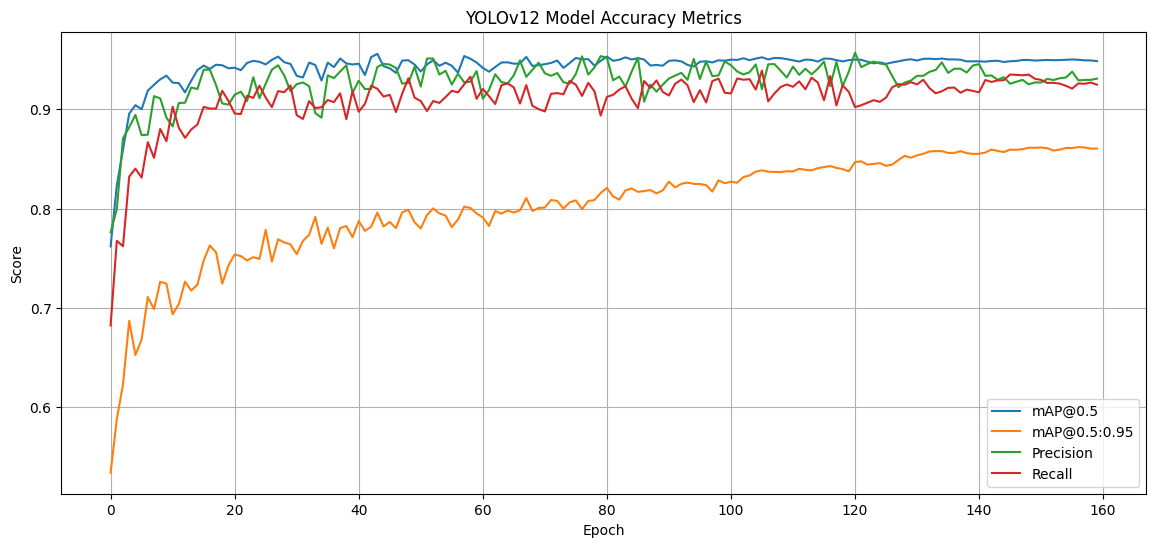

In [2]:
plt.figure(figsize=(14, 6))

plt.plot(df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.plot(df["metrics/precision(B)"], label="Precision")
plt.plot(df["metrics/recall(B)"], label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLOv12 Model Accuracy Metrics")
plt.legend()
plt.grid(True)
plt.show()

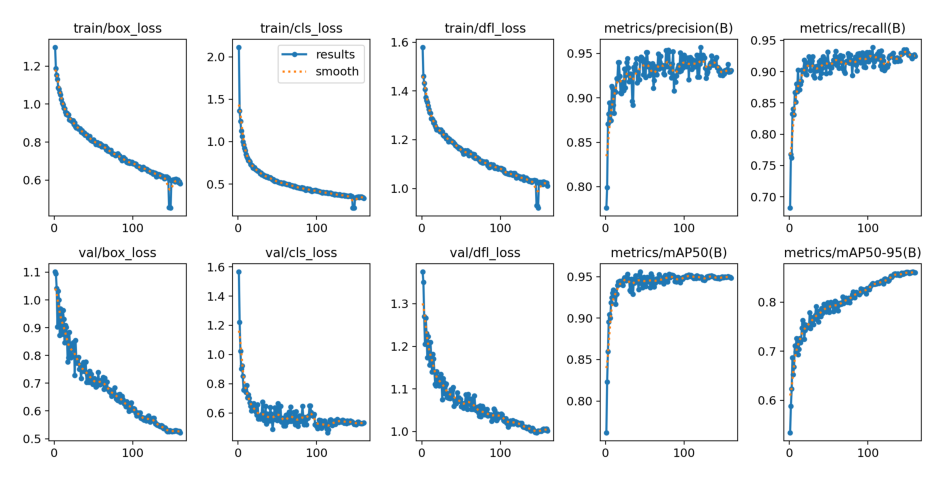

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/train/results.png")
plt.figure(figsize=(12,6))
plt.imshow(img)
plt.axis("off")
plt.show()